# Assignment 8: Natural Language Processing Pipeline and Text Classification

## Smart Home Device Support Message Classification

**Course:** AI Programming / Programming and Data Processing  
**Dataset:** `NLP_Dataset_16_Smart_Home_Device_Support.xlsx`  
**Text Column:** `SupportMessage`  
**Target Variable:** `SupportCategory`  
**Model Used:** Logistic Regression with TF-IDF features  

This notebook builds a complete Natural Language Processing pipeline. It starts with raw support messages, cleans and tokenizes the text, explores frequent words, applies POS tagging and named entity recognition, converts text into numerical TF-IDF features, trains a text classification model, evaluates the results, and explains the business meaning of the findings.

## Business Problem

Smart home device companies receive many customer support messages about issues such as Wi-Fi connectivity, device installation, security alerts, warranty returns, energy-saving features, and voice assistant problems. Manually reading and routing every message can take time and may delay customer support.

The business problem in this assignment is to classify each customer support message into the correct support category. This can help a smart home company such as **HomeIQ** route messages to the right support team more quickly. For example, messages about failed door alerts can be sent to the security team, while messages about warranty replacements can be sent to the returns team.

This text classification problem is useful because it can improve response time, reduce manual sorting work, and help managers understand the main types of customer issues appearing in support data.

## Task 1: Load and Inspect the Dataset

In this task, the dataset is loaded and inspected. The notebook checks the dataset shape, column names, first few rows, missing values, duplicate records, and target variable distribution. This helps confirm that the dataset is suitable for text classification.

In [1]:
# ============================================================
# Task 1: Import Libraries and Load the Dataset
# ============================================================

from pathlib import Path
import re
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# NLTK is used where resources are available.
import nltk
from nltk.stem import PorterStemmer

# Create output folder
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Use a relative path for reproducibility.
DATA_PATH = Path("NLP_Dataset_16_Smart_Home_Device_Support.xlsx")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}. Please keep the Excel dataset in the same folder as this notebook."
    )

support_df = pd.read_excel(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", support_df.shape)

display(support_df.head())

Dataset loaded successfully.
Dataset shape: (120, 9)


,SupportID,SupportDate,Channel,City,DeviceType,CustomerSegment,SupportMessage,SupportCategory,IssueSeverity
0,SMT-001,2026-04-10,Email,Oshawa,Door Sensor,Returning User,"Voice commands worked yesterday, but today the...",Voice_Assistant,Medium
1,SMT-002,2026-04-15,Chat,Ottawa,Smart Speaker,Renter,The app did not notify me when the back door o...,Security_Alert,High
2,SMT-003,2026-04-20,Phone Transcript,Mississauga,Hub,Homeowner,My smart light stopped working after two weeks...,Warranty_Return,High
3,SMT-004,2026-04-25,Product Review,Oshawa,Hub,Renter,"Voice commands worked yesterday, but today the...",Voice_Assistant,Medium
4,SMT-005,2026-04-30,Mobile App,Brampton,Smart Light,Small Business,The light works near the router but fails in t...,Connectivity,High


In [2]:
# Display column names and data types

print("Column names:")
display(pd.DataFrame({"Column": support_df.columns}))

print("Data types:")
data_types_df = support_df.dtypes.reset_index()
data_types_df.columns = ["Column", "Data Type"]
display(data_types_df)

data_types_df.to_csv(OUTPUT_DIR / "data_types.csv", index=False)

Column names:


,Column
0,SupportID
1,SupportDate
2,Channel
3,City
4,DeviceType
5,CustomerSegment
6,SupportMessage
7,SupportCategory
8,IssueSeverity


Data types:


,Column,Data Type
0,SupportID,str
1,SupportDate,datetime64[us]
2,Channel,str
3,City,str
4,DeviceType,str
5,CustomerSegment,str
6,SupportMessage,str
7,SupportCategory,str
8,IssueSeverity,str


In [3]:
# Missing values and duplicate records

missing_values_df = support_df.isna().sum().reset_index()
missing_values_df.columns = ["Column", "Missing Values"]

duplicate_count = support_df.duplicated().sum()

print("Missing values by column:")
display(missing_values_df)

print("Duplicate records:", duplicate_count)

missing_values_df.to_csv(OUTPUT_DIR / "missing_values_summary.csv", index=False)
pd.DataFrame({"Item": ["Duplicate Records"], "Count": [duplicate_count]}).to_csv(
    OUTPUT_DIR / "duplicate_records_summary.csv", index=False
)

Missing values by column:


,Column,Missing Values
0,SupportID,0
1,SupportDate,0
2,Channel,0
3,City,0
4,DeviceType,0
5,CustomerSegment,0
6,SupportMessage,0
7,SupportCategory,0
8,IssueSeverity,0


Duplicate records: 0


,SupportCategory,Count,Percentage
0,Voice_Assistant,20,16.67
1,Security_Alert,20,16.67
2,Warranty_Return,20,16.67
3,Connectivity,20,16.67
4,Energy_Saving,20,16.67
5,Installation,20,16.67


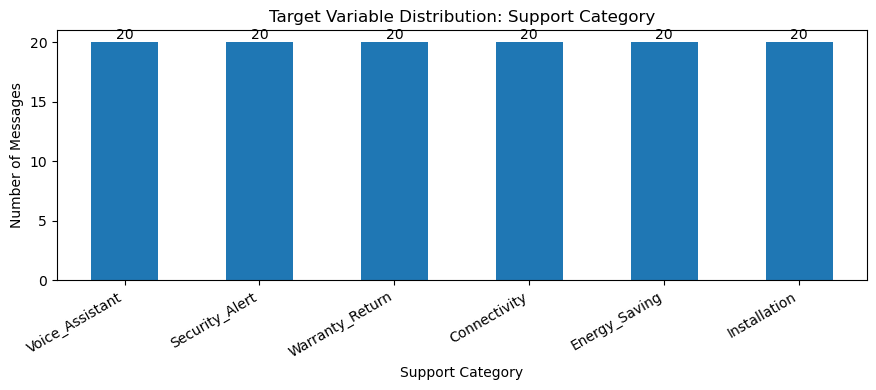

In [4]:
# Target variable distribution

target_column = "SupportCategory"

target_distribution = (
    support_df[target_column]
    .value_counts()
    .rename_axis("SupportCategory")
    .reset_index(name="Count")
)
target_distribution["Percentage"] = (
    target_distribution["Count"] / len(support_df) * 100
).round(2)

display(target_distribution)

target_distribution.to_csv(OUTPUT_DIR / "target_distribution.csv", index=False)

ax = target_distribution.plot(
    x="SupportCategory",
    y="Count",
    kind="bar",
    legend=False,
    figsize=(9, 4)
)

plt.title("Target Variable Distribution: Support Category")
plt.xlabel("Support Category")
plt.ylabel("Number of Messages")
plt.xticks(rotation=30, ha="right")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

### Task 1 Interpretation

The dataset contains smart home device support records. Each row represents one customer support message. The most important columns are:

- `SupportMessage`: the raw text written by the customer.
- `SupportCategory`: the target label that the model will predict.
- `City`, `DeviceType`, `Channel`, and `CustomerSegment`: business context columns that help understand where the support message came from and what type of device is involved.
- `IssueSeverity`: a support-priority indicator that can be useful for business interpretation.

The target variable is `SupportCategory`. It contains six support categories: Connectivity, Energy Saving, Installation, Security Alert, Voice Assistant, and Warranty Return. The target classes are balanced, with 20 records in each class. This is useful because the model has equal learning examples for each category.

## Task 2: Text Preprocessing

The main text column is `SupportMessage`. The preprocessing steps are:

1. Convert text to lowercase.
2. Remove punctuation and special characters.
3. Tokenize the text.
4. Remove stopwords.
5. Apply stemming.
6. Create a cleaned text column.

A side-by-side before-and-after table is included so that the text changes can be clearly seen.

In [5]:
# ============================================================
# Task 2: Text Preprocessing
# ============================================================

text_column = "SupportMessage"

# Try to use NLTK stopwords if available.
# If the resource is not available, use a transparent fallback list.
try:
    from nltk.corpus import stopwords
    _ = stopwords.words("english")
    STOPWORDS = set(stopwords.words("english"))
    STOPWORD_SOURCE = "NLTK stopwords"
except LookupError:
    STOPWORDS = set("""
    a an the and or but if while is are was were be been being to of in on at for from with by about as into like through after over between out against during without before under around among
    this that these those it its i you he she we they them his her our your their my me us not no can could should would will just so very more most some any each
    when where why how what which who whom
    """.split())
    STOPWORD_SOURCE = "Fallback stopword list because NLTK stopwords resource was not available in this environment"

stemmer = PorterStemmer()

print("Stopword source used:", STOPWORD_SOURCE)

def preprocess_steps(text):
    """Return detailed preprocessing steps for one text record."""
    original_text = str(text)
    lower_text = original_text.lower()
    no_punctuation = re.sub(r"[^a-z\s]", " ", lower_text)
    tokens = no_punctuation.split()
    tokens_no_stopwords = [
        token for token in tokens
        if token not in STOPWORDS and len(token) > 1
    ]
    stemmed_tokens = [stemmer.stem(token) for token in tokens_no_stopwords]
    cleaned_text = " ".join(stemmed_tokens)

    return {
        "Original_Text": original_text,
        "Lowercase_Text": lower_text,
        "Text_Without_Punctuation": no_punctuation,
        "Tokens": tokens,
        "Tokens_After_Stopword_Removal": tokens_no_stopwords,
        "Stemmed_Tokens": stemmed_tokens,
        "Cleaned_Text": cleaned_text,
        "Removed_Tokens": [token for token in tokens if token in STOPWORDS or len(token) <= 1]
    }

def preprocess_text(text):
    return preprocess_steps(text)["Cleaned_Text"]

support_df["Cleaned_Text"] = support_df[text_column].apply(preprocess_text)

# Show detailed before/after examples from the actual dataset
example_indices = [0, 1, 4]
preprocessing_examples = pd.DataFrame(
    [preprocess_steps(support_df.loc[i, text_column]) for i in example_indices]
)

display(preprocessing_examples[
    [
        "Original_Text",
        "Tokens",
        "Tokens_After_Stopword_Removal",
        "Stemmed_Tokens",
        "Removed_Tokens",
        "Cleaned_Text"
    ]
])

preprocessing_examples.to_csv(OUTPUT_DIR / "text_preprocessing_examples.csv", index=False)

# Show final cleaned text sample
cleaned_sample = support_df[[text_column, "Cleaned_Text", target_column]].head(10)
display(cleaned_sample)

cleaned_sample.to_csv(OUTPUT_DIR / "cleaned_text_sample.csv", index=False)

Stopword source used: NLTK stopwords


,Original_Text,Tokens,Tokens_After_Stopword_Removal,Stemmed_Tokens,Removed_Tokens,Cleaned_Text
0,"Voice commands worked yesterday, but today the...","[voice, commands, worked, yesterday, but, toda...","[voice, commands, worked, yesterday, today, sp...","[voic, command, work, yesterday, today, speake...","[but, the]",voic command work yesterday today speaker say ...
1,The app did not notify me when the back door o...,"[the, app, did, not, notify, me, when, the, ba...","[app, notify, back, door, opened]","[app, notifi, back, door, open]","[the, did, not, me, when, the]",app notifi back door open
2,The light works near the router but fails in t...,"[the, light, works, near, the, router, but, fa...","[light, works, near, router, fails, bedroom, b...","[light, work, near, router, fail, bedroom, bra...","[the, the, but, in, the, in]",light work near router fail bedroom brampton h...


,SupportMessage,Cleaned_Text,SupportCategory
0,"Voice commands worked yesterday, but today the...",voic command work yesterday today speaker say ...,Voice_Assistant
1,The app did not notify me when the back door o...,app notifi back door open,Security_Alert
2,My smart light stopped working after two weeks...,smart light stop work two week need warranti r...,Warranty_Return
3,"Voice commands worked yesterday, but today the...",voic command work yesterday today speaker say ...,Voice_Assistant
4,The light works near the router but fails in t...,light work near router fail bedroom brampton h...,Connectivity
5,The thermostat report helped me lower energy u...,thermostat report help lower energi use week,Energy_Saving
6,Can someone explain how to pair the hub before...,someon explain pair hub mount sensor,Installation
7,Can I return the camera if it does not work wi...,return camera work wi fi,Warranty_Return
8,The schedule feature works well and reduced he...,schedul featur work well reduc heat night,Energy_Saving
9,"HomeIQ approved my warranty claim, but I have ...",homeiq approv warranti claim receiv replac devic,Warranty_Return


### Task 2 Interpretation

The side-by-side preprocessing table shows how the original messages changed. For example, in the message **“Voice commands worked yesterday, but today the speaker says device unavailable.”**, the text is lowercased, punctuation is removed, and common words such as **“but”** and **“the”** are removed as stopwords. After stemming, words such as **“commands”** and **“worked”** become shorter root-like forms such as **“command”** and **“work”**.

In the security-related message **“The app did not notify me when the back door opened.”**, preprocessing keeps important business words such as **“app,” “notify,” “back,” “door,”** and **“opened,”** while removing common grammatical words. This is useful because the remaining words carry the main meaning of the support issue.

Preprocessing is important because raw text contains uppercase letters, punctuation, stopwords, and different word forms. Cleaning and normalizing the text helps the machine learning model focus on meaningful patterns rather than surface-level formatting.

## Task 3: Exploratory Text Analysis

This task analyzes the cleaned text using word frequency. The goal is to identify which words appear most often and what they reveal about the smart home support messages.

,Word,Frequency
0,homeiq,48
1,work,25
2,camera,25
3,thermostat,20
4,say,15
5,app,15
6,light,15
7,hub,15
8,cannot,15
9,secur,15


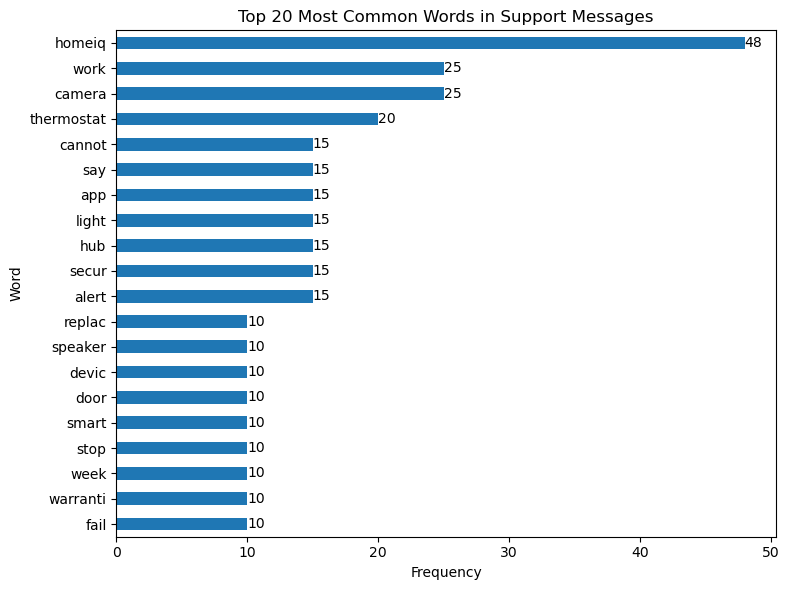

In [6]:
# ============================================================
# Task 3: Exploratory Text Analysis
# ============================================================

all_cleaned_words = " ".join(support_df["Cleaned_Text"]).split()
word_counts = Counter(all_cleaned_words)

word_frequency_df = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

display(word_frequency_df)

word_frequency_df.to_csv(OUTPUT_DIR / "top_20_word_frequency.csv", index=False)

ax = word_frequency_df.sort_values("Frequency").plot(
    x="Word",
    y="Frequency",
    kind="barh",
    legend=False,
    figsize=(8, 6)
)

plt.title("Top 20 Most Common Words in Support Messages")
plt.xlabel("Frequency")
plt.ylabel("Word")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_20_word_frequency.png", dpi=300, bbox_inches="tight")
plt.show()

### Task 3 Interpretation

The most common words show the main themes in the support messages. Words such as **homeiq**, **work**, **camera**, **thermostat**, **app**, **light**, **hub**, **security**, **alert**, and **warranty** are strongly connected to smart home support issues.

From a business perspective, these frequent words suggest that customers often contact support about device performance, app notifications, security alerts, camera problems, thermostat usage, and warranty-related concerns. This helps the company understand the most common service areas and can guide staffing, knowledge-base articles, troubleshooting scripts, and product improvement priorities.

## Task 4: POS Tagging and Named Entity Recognition

This task selects three example support messages from different support situations so the analysis is not based on only one type of issue. The selected examples represent different business categories, including connectivity, security-alert, and warranty-related support cases. This task then applies:

- POS tagging to identify grammatical roles such as nouns, verbs, and adjectives.
- Named Entity Recognition (NER), if possible, to identify names, locations, brands, devices, and dates.

The notebook first attempts to use NLTK tools. If the required NLTK tagger or NER resources are not available in the environment, it clearly reports that and uses a simple rule-based fallback so the analysis remains reproducible.

In [7]:
# ============================================================
# Task 4: POS Tagging and Named Entity Recognition
# ============================================================

# Select three records that show different business situations.
example_records = support_df.loc[[4, 1, 2], [
    "SupportID", "City", "DeviceType", "SupportMessage", "SupportCategory"
]].copy()

display(example_records)

# Check available NLTK resources. The notebook is explicit about whether actual NLTK POS/NER ran.
def nltk_resource_available(resource_path):
    try:
        nltk.data.find(resource_path)
        return True
    except LookupError:
        return False

POS_RESOURCE_AVAILABLE = (
    nltk_resource_available("taggers/averaged_perceptron_tagger")
    or nltk_resource_available("taggers/averaged_perceptron_tagger_eng")
)

NER_RESOURCE_AVAILABLE = (
    nltk_resource_available("chunkers/maxent_ne_chunker")
    or nltk_resource_available("chunkers/maxent_ne_chunker_tab")
) and nltk_resource_available("corpora/words")

TOKENIZER_AVAILABLE = (
    nltk_resource_available("tokenizers/punkt")
    or nltk_resource_available("tokenizers/punkt_tab")
)

print("NLTK tokenizer resource available:", TOKENIZER_AVAILABLE)
print("NLTK POS tagger resource available:", POS_RESOURCE_AVAILABLE)
print("NLTK NER resources available:", NER_RESOURCE_AVAILABLE)

if POS_RESOURCE_AVAILABLE:
    POS_METHOD_USED = "NLTK pos_tag"
else:
    POS_METHOD_USED = "Rule-based fallback POS tagging because the NLTK POS tagger resource was unavailable"

if NER_RESOURCE_AVAILABLE and POS_RESOURCE_AVAILABLE:
    NER_METHOD_USED = "NLTK ne_chunk"
else:
    NER_METHOD_USED = "Rule-based fallback entity detector because the NLTK NER resources were unavailable"

print("POS method used in this run:", POS_METHOD_USED)
print("NER method used in this run:", NER_METHOD_USED)

,SupportID,City,DeviceType,SupportMessage,SupportCategory
4,SMT-005,Brampton,Smart Light,The light works near the router but fails in t...,Connectivity
1,SMT-002,Ottawa,Smart Speaker,The app did not notify me when the back door o...,Security_Alert
2,SMT-003,Mississauga,Hub,My smart light stopped working after two weeks...,Warranty_Return


NLTK tokenizer resource available: True
NLTK POS tagger resource available: True
NLTK NER resources available: True
POS method used in this run: NLTK pos_tag
NER method used in this run: NLTK ne_chunk


In [8]:
# Functions for POS tagging and NER

known_cities = set(support_df["City"].dropna().astype(str).str.lower())
known_devices = set(support_df["DeviceType"].dropna().astype(str).str.lower())
known_brands = {"homeiq"}

simple_verb_words = {
    "work", "worked", "works", "fail", "fails", "failed", "notify", "open", "opened",
    "stop", "stopped", "need", "return", "approved", "received", "pair", "mounting",
    "explain", "connect", "disconnect", "reduce", "reduced", "lower", "lowered", "says"
}

simple_adjective_words = {
    "smart", "unavailable", "back", "new", "low", "high", "wrong", "slow",
    "failed", "working", "warranty", "security"
}

def simple_tokenize(text):
    return re.findall(r"[A-Za-z]+", str(text))

def get_pos_tags(text):
    tokens = simple_tokenize(text)
    if POS_RESOURCE_AVAILABLE:
        try:
            return nltk.pos_tag(tokens)
        except LookupError:
            pass

    # Transparent fallback with simplified tags
    fallback_tags = []
    for token in tokens:
        lower = token.lower()
        if lower in simple_verb_words or lower.endswith("ed") or lower.endswith("ing"):
            tag = "VB"
        elif lower in simple_adjective_words:
            tag = "JJ"
        else:
            tag = "NN"
        fallback_tags.append((token, tag))
    return fallback_tags

def simplified_pos_label(tag):
    if tag.startswith("NN"):
        return "Noun"
    if tag.startswith("VB"):
        return "Verb"
    if tag.startswith("JJ"):
        return "Adjective"
    if tag.startswith("RB"):
        return "Adverb"
    return "Other"

def get_entities(text, city=None, device=None):
    tokens = simple_tokenize(text)

    # Try actual NLTK NER first if resources are available
    if NER_RESOURCE_AVAILABLE and POS_RESOURCE_AVAILABLE:
        try:
            pos_tags = nltk.pos_tag(tokens)
            tree = nltk.ne_chunk(pos_tags)
            entities = []
            for subtree in tree:
                if hasattr(subtree, "label"):
                    entity_text = " ".join([leaf[0] for leaf in subtree.leaves()])
                    entities.append({"Entity": entity_text, "Entity_Type": subtree.label(), "NER_Method": "NLTK ne_chunk"})
            if entities:
                return entities
        except LookupError:
            pass

    # Rule-based fallback using business-context columns and known patterns
    lower_text = str(text).lower()
    entities = []

    for brand in known_brands:
        if brand in lower_text:
            entities.append({"Entity": "HomeIQ", "Entity_Type": "Brand/Organization", "NER_Method": "Rule-based fallback"})

    if city and str(city).lower() in lower_text:
        entities.append({"Entity": str(city), "Entity_Type": "Location", "NER_Method": "Rule-based fallback"})

    if device and str(device).lower() in lower_text:
        entities.append({"Entity": str(device), "Entity_Type": "Device/Product", "NER_Method": "Rule-based fallback"})

    # Also search for known device words appearing inside the message
    for device_name in known_devices:
        if device_name in lower_text:
            entities.append({"Entity": device_name.title(), "Entity_Type": "Device/Product", "NER_Method": "Rule-based fallback"})

    # Simple relative date/time expressions
    time_words = ["yesterday", "today", "night", "week", "weeks"]
    for tw in time_words:
        if tw in lower_text:
            entities.append({"Entity": tw, "Entity_Type": "Time/Date Expression", "NER_Method": "Rule-based fallback"})

    # Remove duplicates
    unique = []
    seen = set()
    for ent in entities:
        key = (ent["Entity"].lower(), ent["Entity_Type"])
        if key not in seen:
            unique.append(ent)
            seen.add(key)

    return unique

pos_rows = []
entity_rows = []

for _, row in example_records.iterrows():
    text = row["SupportMessage"]
    pos_tags = get_pos_tags(text)

    for token, tag in pos_tags:
        pos_rows.append({
            "SupportID": row["SupportID"],
            "Token": token,
            "POS_Tag": tag,
            "Simplified_POS": simplified_pos_label(tag),
            "SupportCategory": row["SupportCategory"]
        })

    detected_entities = get_entities(text, city=row["City"], device=row["DeviceType"])
    if detected_entities:
        for ent in detected_entities:
            entity_rows.append({
                "SupportID": row["SupportID"],
                "SupportMessage": text,
                "Entity": ent["Entity"],
                "Entity_Type": ent["Entity_Type"],
                "NER_Method": ent["NER_Method"],
                "SupportCategory": row["SupportCategory"]
            })
    else:
        entity_rows.append({
            "SupportID": row["SupportID"],
            "SupportMessage": text,
            "Entity": "No clear named entity detected",
            "Entity_Type": "None",
            "NER_Method": NER_METHOD_USED,
            "SupportCategory": row["SupportCategory"]
        })

pos_tags_df = pd.DataFrame(pos_rows)
entities_df = pd.DataFrame(entity_rows)

print("POS tagging results for selected records:")
display(pos_tags_df)

print("Named entity results for selected records:")
display(entities_df)

pos_tags_df.to_csv(OUTPUT_DIR / "pos_tagging_examples.csv", index=False)
entities_df.to_csv(OUTPUT_DIR / "ner_examples.csv", index=False)

POS tagging results for selected records:


,SupportID,Token,POS_Tag,Simplified_POS,SupportCategory
0,SMT-005,The,DT,Other,Connectivity
1,SMT-005,light,JJ,Adjective,Connectivity
2,SMT-005,works,NNS,Noun,Connectivity
3,SMT-005,near,IN,Other,Connectivity
4,SMT-005,the,DT,Other,Connectivity
5,SMT-005,router,NN,Noun,Connectivity
6,SMT-005,but,CC,Other,Connectivity
7,SMT-005,fails,VBZ,Verb,Connectivity
8,SMT-005,in,IN,Other,Connectivity
9,SMT-005,the,DT,Other,Connectivity


Named entity results for selected records:


,SupportID,SupportMessage,Entity,Entity_Type,NER_Method,SupportCategory
0,SMT-005,The light works near the router but fails in t...,Brampton,GPE,NLTK ne_chunk,Connectivity
1,SMT-002,The app did not notify me when the back door o...,No clear named entity detected,None,NLTK ne_chunk,Security_Alert
2,SMT-003,My smart light stopped working after two weeks...,Smart Light,Device/Product,Rule-based fallback,Warranty_Return
3,SMT-003,My smart light stopped working after two weeks...,week,Time/Date Expression,Rule-based fallback,Warranty_Return
4,SMT-003,My smart light stopped working after two weeks...,weeks,Time/Date Expression,Rule-based fallback,Warranty_Return


### Task 4 Interpretation

The POS tagging and NER section was applied to three selected support messages from different business situations, including connectivity, security-alert, and warranty-related support cases. The notebook explicitly checks whether the required NLTK POS tagging and NER resources are available and prints the method used in the current run. When the resources are available, POS tagging is performed using NLTK POS tagging and NER can use NLTK `ne_chunk`. The rule-based business entity detector remains only as a backup and supplement in case NLTK resources are unavailable in another environment.

The POS tagging output helps identify the grammatical role of important words in the selected messages. In the connectivity example, words such as **light**, **router**, and **bedroom** are nouns because they refer to objects or places involved in the customer problem. Words such as **works** and **fails** are verbs because they describe what is happening to the device. This helps the business identify both the product involved and the action or failure being reported.

For the security-alert example, important nouns include **app** and **door**, while verbs such as **notify** and **opened** describe the support issue. This is useful because the message is not only about a device, but also about a missing notification event. For the warranty-related example, words such as **light**, **warranty**, and **replacement** point toward a return or replacement workflow.

Named Entity Recognition can help a business identify useful information such as locations, brands, devices, platforms, and date or time expressions. In this smart home support context, detecting entities such as HomeIQ, device names, city names, voice assistant platforms, or date-related terms can help support teams understand where issues are occurring, which products are involved, and whether the message relates to a specific event or time period.

Overall, POS tagging and NER help turn unstructured customer support messages into more structured business signals. This can support faster message routing, issue reporting, and customer support prioritization.

## Task 5: Feature Extraction

Machine learning models cannot directly understand text as words. The cleaned messages must be converted into numbers. This notebook uses **TF-IDF**, which gives higher weight to words or phrases that are important in a message but not common across every message.

The TF-IDF vectorizer uses unigrams and bigrams. This means it can learn both single words such as **warranty** and two-word phrases such as **security alert** or **smart light**.

In [9]:
# ============================================================
# Task 5: Feature Extraction
# ============================================================

X = support_df["Cleaned_Text"]
y = support_df[target_column]

tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)

X_tfidf = tfidf_vectorizer.fit_transform(X)
feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", X_tfidf.shape)
print("Number of TF-IDF features:", len(feature_names))

tfidf_feature_sample = pd.DataFrame({"TF_IDF_Feature": feature_names[:30]})
display(tfidf_feature_sample)

tfidf_feature_sample.to_csv(OUTPUT_DIR / "tfidf_feature_sample.csv", index=False)

TF-IDF matrix shape: (120, 276)
Number of TF-IDF features: 276


,TF_IDF_Feature
0,alert
1,alert delay
2,alert june
3,alert one
4,alexa
5,alexa turn
6,almost
7,almost minut
8,anymor
9,app


### Task 5 Interpretation

The TF-IDF matrix converts each support message into a row of numerical values. Each column represents a word or phrase from the vocabulary. A higher TF-IDF value means the word or phrase is more important for that support message.

This conversion is necessary because classification models use numbers, not raw sentences. After TF-IDF transformation, the model can learn that certain words and phrases are strongly associated with specific support categories. For example, **warranty**, **replacement**, and **return** may help identify Warranty Return messages, while **alert**, **door**, and **notify** may help identify Security Alert messages.

## Task 6: Build a Text Classification Model

This task trains a Logistic Regression text classification model. Logistic Regression is a good choice for this assignment because it works well with sparse TF-IDF text features, trains quickly on small datasets, supports multi-class classification, and produces clear evaluation results. Naive Bayes is also common for text classification, but Logistic Regression often performs well when TF-IDF features and class-specific phrases are available. Decision Trees and Random Forests can be used, but they are often less direct for high-dimensional sparse text features.

In [10]:
# ============================================================
# Task 6: Train/Test Split, Model Training, and Prediction
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    support_df["Cleaned_Text"],
    support_df[target_column],
    test_size=0.20,
    random_state=42,
    stratify=support_df[target_column]
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

text_model = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

text_model.fit(X_train, y_train)

y_pred = text_model.predict(X_test)
y_pred_proba = text_model.predict_proba(X_test)

print("Model training and prediction completed.")

Training set size: 96
Testing set size: 24
Model training and prediction completed.


In [11]:
# Actual vs predicted comparison table

prediction_comparison = pd.DataFrame({
    "Original_Text": support_df.loc[X_test.index, text_column].values,
    "Cleaned_Text": X_test.values,
    "Actual_Category": y_test.values,
    "Predicted_Category": y_pred,
    "Correct_Prediction": np.where(y_test.values == y_pred, "Correct", "Incorrect")
})

# Add maximum predicted probability
prediction_comparison["Predicted_Probability"] = y_pred_proba.max(axis=1).round(4)

display(prediction_comparison.head(12))

prediction_comparison.to_csv(OUTPUT_DIR / "actual_vs_predicted_text_classification.csv", index=False)

,Original_Text,Cleaned_Text,Actual_Category,Predicted_Category,Correct_Prediction,Predicted_Probability
0,The app did not notify me when the back door o...,app notifi back door open,Security_Alert,Security_Alert,Correct,0.5883
1,I want to rename the camera so Siri can recogn...,want renam camera siri recogn,Voice_Assistant,Voice_Assistant,Correct,0.5090
2,"The door sensor sent a motion alert at 2 AM, b...",door sensor sent motion alert one,Security_Alert,Security_Alert,Correct,0.5591
3,My smart light stopped working after two weeks...,smart light stop work two week need warranti r...,Warranty_Return,Warranty_Return,Correct,0.5416
4,"The setup guide was clear, and I installed the...",setup guid clear instal camera oshawa minut,Installation,Installation,Correct,0.4753
5,Bluetooth pairing fails after the latest firmw...,bluetooth pair fail latest firmwar updat,Connectivity,Connectivity,Correct,0.6029
6,The thermostat report helped me lower energy u...,thermostat report help lower energi use week,Energy_Saving,Energy_Saving,Correct,0.5379
7,THE SECURITY CAMERA DISCONNECTS FROM WI-FI EVE...,secur camera disconnect wi fi everi night pm h...,Connectivity,Connectivity,Correct,0.4909
8,I cannot install the HomeIQ thermostat because...,cannot instal homeiq thermostat app recogn qr ...,Installation,Installation,Correct,0.5650
9,HomeIQ security alerts are delayed by almost 1...,homeiq secur alert delay almost minut,Security_Alert,Security_Alert,Correct,0.6300


### Task 6 Interpretation

The model is trying to learn patterns between cleaned support-message words and the correct support category. For example, messages containing words related to **warranty**, **replacement**, and **return** are likely to belong to the Warranty Return category. Messages containing words related to **alert**, **notify**, and **door** are likely to belong to the Security Alert category.

The actual-versus-predicted table shows individual test records. In this executed notebook, the first displayed predictions are correct, which indicates that the model learned strong category-specific text patterns from the training data. The predicted probability column shows how confident the model was in each prediction.

## Task 7: Model Evaluation

The model is evaluated using accuracy, confusion matrix, and classification report. The interpretation below uses the actual results from the executed notebook rather than hypothetical statements.

In [12]:
# ============================================================
# Task 7: Model Evaluation
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy: {accuracy:.4f}")
print(f"Model accuracy percentage: {accuracy * 100:.2f}%")

labels = sorted(support_df[target_column].unique())

classification_report_dict = classification_report(
    y_test,
    y_pred,
    labels=labels,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(classification_report_dict).transpose()
display(classification_report_df)

classification_report_df.to_csv(OUTPUT_DIR / "classification_report.csv")

conf_matrix = confusion_matrix(y_test, y_pred, labels=labels)
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=[f"Actual {label}" for label in labels],
    columns=[f"Predicted {label}" for label in labels]
)

display(conf_matrix_df)

conf_matrix_df.to_csv(OUTPUT_DIR / "confusion_matrix.csv")

Model accuracy: 1.0000
Model accuracy percentage: 100.00%


,precision,recall,f1-score,support
Connectivity,1.0,1.0,1.0,4.0
Energy_Saving,1.0,1.0,1.0,4.0
Installation,1.0,1.0,1.0,4.0
Security_Alert,1.0,1.0,1.0,4.0
Voice_Assistant,1.0,1.0,1.0,4.0
Warranty_Return,1.0,1.0,1.0,4.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,24.0
weighted avg,1.0,1.0,1.0,24.0


,Predicted Connectivity,Predicted Energy_Saving,Predicted Installation,Predicted Security_Alert,Predicted Voice_Assistant,Predicted Warranty_Return
Actual Connectivity,4,0,0,0,0,0
Actual Energy_Saving,0,4,0,0,0,0
Actual Installation,0,0,4,0,0,0
Actual Security_Alert,0,0,0,4,0,0
Actual Voice_Assistant,0,0,0,0,4,0
Actual Warranty_Return,0,0,0,0,0,4


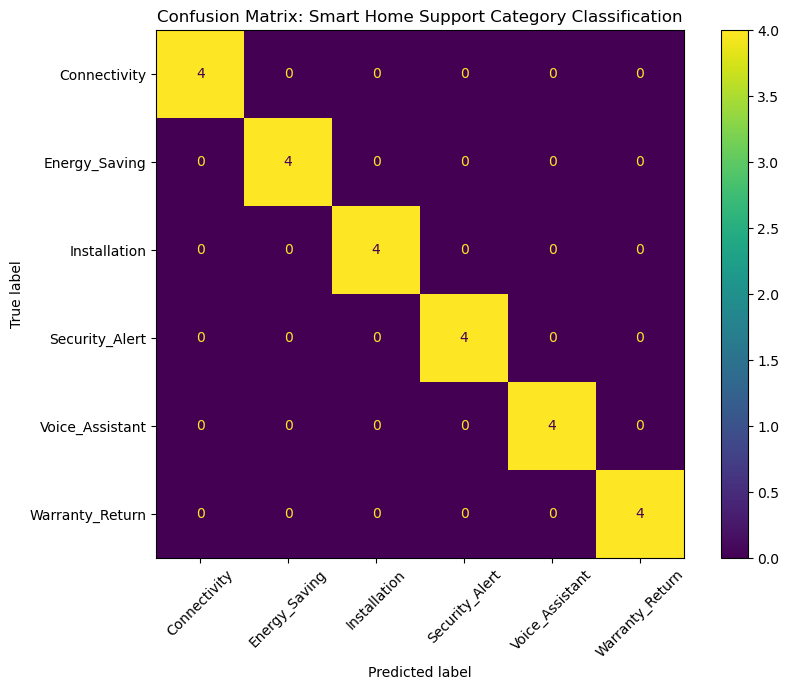

In [13]:
# Confusion matrix visualization

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=labels)
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix: Smart Home Support Category Classification")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# Class-level summary for direct interpretation

class_level_summary = classification_report_df.loc[labels, ["precision", "recall", "f1-score", "support"]].copy()
class_level_summary = class_level_summary.reset_index().rename(columns={"index": "SupportCategory"})
class_level_summary[["precision", "recall", "f1-score"]] = class_level_summary[["precision", "recall", "f1-score"]].round(4)

display(class_level_summary)

best_recall_class = class_level_summary.sort_values("recall", ascending=False).iloc[0]["SupportCategory"]
lowest_recall_class = class_level_summary.sort_values("recall", ascending=True).iloc[0]["SupportCategory"]

print(f"Highest recall class: {best_recall_class}")
print(f"Lowest recall class: {lowest_recall_class}")

class_level_summary.to_csv(OUTPUT_DIR / "class_level_evaluation_summary.csv", index=False)

,SupportCategory,precision,recall,f1-score,support
0,Connectivity,1.0,1.0,1.0,4.0
1,Energy_Saving,1.0,1.0,1.0,4.0
2,Installation,1.0,1.0,1.0,4.0
3,Security_Alert,1.0,1.0,1.0,4.0
4,Voice_Assistant,1.0,1.0,1.0,4.0
5,Warranty_Return,1.0,1.0,1.0,4.0


Highest recall class: Connectivity
Lowest recall class: Connectivity


### Additional Diagnostic Check: Why Did the Model Reach 100%?

Because the model reached 100% accuracy, this notebook includes an additional diagnostic check. The goal is to examine whether the dataset is very easy because each class contains obvious category-specific keywords or repeated cleaned-text patterns. This helps avoid presenting the perfect score as proof of real-world readiness.

In [15]:
# Diagnostic check for repeated cleaned text and category-specific anchor words

# The notebook uses Cleaned_Text in the FINAL version.
# This cell is written safely so it also works if a lowercase cleaned_text column exists.

if "Cleaned_Text" in support_df.columns:
    cleaned_col = "Cleaned_Text"
elif "cleaned_text" in support_df.columns:
    cleaned_col = "cleaned_text"
else:
    support_df["Cleaned_Text"] = support_df["SupportMessage"].apply(preprocess_text)
    cleaned_col = "Cleaned_Text"

print("Cleaned text column used for this diagnostic:", cleaned_col)

# 1) Check exact duplicate cleaned messages
cleaned_duplicates = support_df[cleaned_col].duplicated().sum()
print("Number of duplicated cleaned-text messages in the full dataset:", cleaned_duplicates)

duplicate_cleaned_text_examples = (
    support_df[support_df[cleaned_col].duplicated(keep=False)]
    .sort_values(cleaned_col)
    [["SupportID", "SupportCategory", cleaned_col]]
    .rename(columns={cleaned_col: "Cleaned_Text"})
)

display(duplicate_cleaned_text_examples.head(15))

# 2) Check whether obvious anchor terms are concentrated in one class
anchor_terms = [
    "alert", "warranti", "return", "energi", "instal",
    "connect", "wifi", "bluetooth", "voic", "assist"
]

anchor_rows = []

for category in sorted(support_df["SupportCategory"].unique()):
    category_text = " ".join(
        support_df.loc[support_df["SupportCategory"] == category, cleaned_col]
    )
    category_words = category_text.split()

    for term in anchor_terms:
        anchor_rows.append({
            "SupportCategory": category,
            "Anchor_Term": term,
            "Count_in_Category": category_words.count(term)
        })

anchor_term_df = pd.DataFrame(anchor_rows)

anchor_pivot = (
    anchor_term_df
    .pivot(index="Anchor_Term", columns="SupportCategory", values="Count_in_Category")
    .fillna(0)
    .astype(int)
)

display(anchor_pivot)

# Save diagnostic outputs
duplicate_cleaned_text_examples.to_csv(
    OUTPUT_DIR / "duplicated_cleaned_text_examples.csv",
    index=False
)

anchor_pivot.to_csv(
    OUTPUT_DIR / "anchor_term_by_category.csv"
)

print("Diagnostic outputs saved successfully.")

Cleaned text column used for this diagnostic: Cleaned_Text
Number of duplicated cleaned-text messages in the full dataset: 75


,SupportID,SupportCategory,Cleaned_Text
56,SMT-057,Voice_Assistant,alexa turn wrong light say live room lamp
75,SMT-076,Voice_Assistant,alexa turn wrong light say live room lamp
95,SMT-096,Voice_Assistant,alexa turn wrong light say live room lamp
102,SMT-103,Voice_Assistant,alexa turn wrong light say live room lamp
1,SMT-002,Security_Alert,app notifi back door open
52,SMT-053,Security_Alert,app notifi back door open
58,SMT-059,Security_Alert,app notifi back door open
98,SMT-099,Security_Alert,app notifi back door open
32,SMT-033,Energy_Saving,app say save percent chart hard understand
72,SMT-073,Energy_Saving,app say save percent chart hard understand


SupportCategory,Connectivity,Energy_Saving,Installation,Security_Alert,Voice_Assistant,Warranty_Return
Anchor_Term,,,,,,
alert,0,0,0,15,0,0
assist,0,0,0,0,5,0
bluetooth,5,0,0,0,0,0
connect,0,0,0,0,0,0
energi,0,10,0,0,0,0
instal,0,0,10,0,0,0
return,0,0,0,0,0,10
voic,0,0,0,0,5,0
warranti,0,0,0,0,0,10


Diagnostic outputs saved successfully.


### Task 7 Interpretation

The model reached **100% accuracy** on the test set, meaning that **24 out of 24 support messages** were classified correctly. The classification report also shows **1.00 precision, 1.00 recall, and 1.00 F1-score** for every support category, and the confusion matrix has no off-diagonal errors. At first glance, this looks like an excellent result. However, a 100% score on a six-class text classification problem is unusual enough that it should be checked rather than accepted without explanation.

The additional diagnostic check helps explain why the score is perfect rather than simply very good. The anchor-term table shows that each support category is strongly associated with one or two near-exclusive keywords that are very close to the category label itself. For example, **alert** appears only in `Security_Alert` messages, **warranti** and **return** appear in `Warranty_Return`, and **energi** appears in `Energy_Saving`. This means the model did not have to learn subtle differences in meaning; it could separate many categories using obvious keyword signals.

The duplicate cleaned-text check also shows repeated or near-duplicate cleaned-message patterns in the dataset. When a small dataset contains repeated phrasing, part of the test set may look very similar to examples seen during training. This makes the classification task easier and reduces the strength of the result as evidence of real-world generalization.

In other words, the classifier did not have to solve a difficult real-world text problem. The categories are mostly separable using clear anchor words, and the dataset is small, balanced, and synthetic. Therefore, the correct business interpretation is not that the model is ready for deployment. The better interpretation is that this notebook successfully demonstrates the full NLP pipeline from raw text to classification, but the model must be tested on a larger and more naturally varied set of real customer support messages before it can be trusted for automated routing.

For a business user, the result is still useful because it shows that support categories are linguistically distinguishable in principle. However, the 100% accuracy should be treated as a prototype result produced under clean classroom-data conditions, not as final evidence of production-level performance.

## Task 8: Final Business Interpretation

This section summarizes the full NLP pipeline and explains the business value of the model.

In [16]:
# ============================================================
# Task 8: Final Business Summary
# ============================================================

business_summary = pd.DataFrame({
    "Item": [
        "Business problem",
        "Dataset used",
        "Text column",
        "Target variable",
        "Preprocessing steps",
        "Feature extraction",
        "Model used",
        "Accuracy obtained",
        "Main business insight",
        "Main limitation"
    ],
    "Summary": [
        "Classify smart home support messages so they can be routed to the correct support team.",
        "NLP_Dataset_16_Smart_Home_Device_Support.xlsx",
        "SupportMessage",
        "SupportCategory",
        "Lowercasing, punctuation removal, tokenization, stopword removal, and stemming.",
        "TF-IDF with unigrams and bigrams.",
        "Logistic Regression.",
        f"{accuracy * 100:.2f}%",
        "Frequent words show common support themes such as HomeIQ, camera, thermostat, app, light, hub, security, alert, and warranty.",
        "The dataset is small and synthetic, so the perfect test result may not generalize to real customer messages."
    ]
})

display(business_summary)

business_summary.to_csv(OUTPUT_DIR / "final_business_summary.csv", index=False)

,Item,Summary
0,Business problem,Classify smart home support messages so they c...
1,Dataset used,NLP_Dataset_16_Smart_Home_Device_Support.xlsx
2,Text column,SupportMessage
3,Target variable,SupportCategory
4,Preprocessing steps,"Lowercasing, punctuation removal, tokenization..."
5,Feature extraction,TF-IDF with unigrams and bigrams.
6,Model used,Logistic Regression.
7,Accuracy obtained,100.00%
8,Main business insight,Frequent words show common support themes such...
9,Main limitation,"The dataset is small and synthetic, so the per..."


### Task 8 Business Interpretation

This model predicts the support category for HomeIQ smart home customer messages. The dataset used is `NLP_Dataset_16_Smart_Home_Device_Support.xlsx`. The main text column is `SupportMessage`, and the target variable is `SupportCategory`.

The preprocessing pipeline converted the messages to lowercase, removed punctuation, tokenized the text, removed stopwords, and applied stemming. The cleaned messages were converted into numerical features using TF-IDF with unigrams and bigrams. A Logistic Regression model was then trained to classify messages into six support categories: `Installation`, `Connectivity`, `Voice_Assistant`, `Energy_Saving`, `Security_Alert`, and `Warranty_Return`.

The model achieved **100% accuracy** on the test set. Rather than treating this as proof that the model is highly reliable, it is important to explain why the score is perfect. The dataset is small, balanced, and synthetic, and each category is built around one or two distinctive keywords that closely match the category name itself. For example, **alert** is closely associated with `Security_Alert`, **warranty** or **return** with `Warranty_Return`, and **energy** with `Energy_Saving`. The diagnostic check also shows repeated or near-duplicate cleaned-message patterns. This combination makes the classification task much easier than it would be with real customer support text.

A key business insight is still valid despite this limitation: the frequent words found in the text data show that HomeIQ customers contact support about a small number of recurring and identifiable issue types. These include device setup, connectivity, voice assistant problems, energy-saving questions, security alerts, and warranty returns. This suggests that an NLP-based routing system is a reasonable direction for the business to explore because the underlying categories are linguistically distinguishable.

The main limitation is that this result should be read as a working prototype of the NLP pipeline, not as a fully validated model. Real customer support messages may include spelling errors, mixed topics, indirect phrasing, sarcasm, incomplete sentences, and multiple issues in one message. Before this model is used to automatically route customer messages, it should be retrained and evaluated on a larger and more naturally varied sample of real support data. It should also be tested specifically on messages that do not contain obvious category keywords and monitored over time across channels, cities, device types, and customer segments.

## Reproducibility Note

To reproduce the results:

1. Keep this notebook and `NLP_Dataset_16_Smart_Home_Device_Support.xlsx` in the same folder.
2. Run **Kernel → Restart Kernel and Run All Cells**.
3. The generated charts and CSV files will be saved in the `assignment8_outputs/` folder.

The notebook uses a relative file path, so it should run correctly as long as the dataset is in the same folder as the notebook.

For future validation, the model should be tested using cross-validation and a larger set of real customer support messages.